# Gamma Trading: Theory and Practice

## Based on Chapter 3 of "The Volatility Smile" by Derman, Miller & Park

This notebook demonstrates **gamma trading** strategies through simulation and theoretical analysis.

### Learning Objectives

By the end of this lecture, you will understand:

- **Delta hedging**: How to neutralize directional exposure using the underlying asset
- **Gamma**: The sensitivity of delta to movements in the underlying price
- **Gamma trading P&L**: How profit/loss depends on realized vs. implied volatility
- **Long gamma positions**: Profitable when realized volatility > implied volatility
- **Short gamma positions**: Profitable when realized volatility < implied volatility
- **Gamma vs. Theta trade-off**: The fundamental relationship between time decay and volatility

---

### Key Concepts

**Delta Hedging**: A strategy to neutralize the directional risk (delta) of an option position by trading the underlying asset.

**Gamma**: The second-order sensitivity measuring how much delta changes as the underlying moves. Gamma is highest for at-the-money options.

**Gamma Trading**: A strategy that profits from the difference between realized and implied volatility through delta hedging.

**Theta**: The time decay of an option's value. Long options lose value each day due to theta.

**The Trade-off**: Long gamma positions benefit from volatility but pay theta. The break-even move is the daily price movement needed to offset theta decay.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Black-Scholes Option Pricing and Greeks

We implement the Black-Scholes formulas to calculate option prices and the Greeks (Delta, Gamma, Theta, Vega) necessary for delta hedging and gamma trading analysis.


In [2]:
def black_scholes_call(S, K, T, r, sigma):
    """
    Calculate the price of a European call option using Black-Scholes formula.
    
    Parameters:
    -----------
    S : float
        Current spot price of the underlying asset
    K : float
        Strike price
    T : float
        Time to maturity (in years)
    r : float
        Risk-free interest rate
    sigma : float
        Implied volatility
        
    Returns:
    --------
    float : Call option price
    """
    if T <= 0:
        return max(S - K, 0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def delta_call(S, K, T, r, sigma):
    """
    Calculate the delta of a European call option.
    Delta measures the sensitivity of option price to changes in underlying price.
    """
    if T <= 0:
        return 1.0 if S > K else 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def gamma(S, K, T, r, sigma):
    """
    Calculate gamma (same for call and put options).
    Gamma measures the sensitivity of delta to changes in underlying price.
    """
    if T <= 0:
        return 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta_call(S, K, T, r, sigma):
    """
    Calculate theta for a European call option (per day).
    Theta measures the time decay of option value.
    """
    if T <= 0:
        return 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) 
             - r * K * np.exp(-r * T) * norm.cdf(d2))
    
    return theta / 365  # Convert to daily theta

def vega(S, K, T, r, sigma):
    """
    Calculate vega (same for call and put options).
    Vega measures sensitivity to volatility changes (per 1% vol change).
    """
    if T <= 0:
        return 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T) / 100

print("Black-Scholes functions defined successfully!")


Black-Scholes functions defined successfully!


## 2. Simulating the Underlying Asset Price

We simulate the path of the underlying asset using a Geometric Brownian Motion (GBM) with a specific **realized volatility**. This allows us to test gamma trading strategies under different volatility scenarios.


In [3]:
def simulate_gbm(S0, mu, sigma_realized, T, n_steps, seed=42):
    """
    Simulate a Geometric Brownian Motion path for the underlying asset.
    
    Parameters:
    -----------
    S0 : float
        Initial stock price
    mu : float
        Drift (expected return rate)
    sigma_realized : float
        Realized volatility
    T : float
        Total time period (in years)
    n_steps : int
        Number of time steps
    seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    prices : array
        Simulated price path
    times : array
        Time points
    """
    np.random.seed(seed)
    
    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)
    
    # Generate Brownian motion increments
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    
    # Initialize price array
    prices = np.zeros(n_steps + 1)
    prices[0] = S0
    
    # Simulate GBM: dS = S * (mu*dt + sigma*dW)
    for i in range(n_steps):
        prices[i + 1] = prices[i] * np.exp((mu - 0.5 * sigma_realized**2) * dt + sigma_realized * dW[i])
    
    return prices, times

print("GBM simulation function defined!")


GBM simulation function defined!


## 3. Gamma Trading Strategy with Delta Hedging

We implement the gamma trading strategy described in Chapter 3:

1. **Buy an ATM call option** (long gamma position)
2. **Delta hedge** by selling the underlying asset
3. **Re-hedge periodically** (discrete rebalancing)
4. **Track total P&L**

### How It Works

- When the underlying moves, delta changes (due to gamma)
- We rebalance the hedge by trading the underlying
- If realized volatility > implied volatility, we profit from the rebalancing
- We pay theta (time decay) each day

The key insight: **Gamma trading P&L depends on the difference between realized and implied volatility**.


In [4]:
def gamma_trading_simulation(S0, K, T, r, sigma_implied, sigma_realized, 
                            n_steps, rehedge_frequency=1, seed=42):
    """
    Simulate a gamma trading strategy with delta hedging.
    
    Parameters:
    -----------
    S0 : float
        Initial stock price
    K : float
        Option strike price
    T : float
        Option maturity (in years)
    r : float
        Risk-free rate
    sigma_implied : float
        Implied volatility used to price the option
    sigma_realized : float
        Realized volatility of the underlying
    n_steps : int
        Total number of time steps
    rehedge_frequency : int
        How often to rehedge (1 = every step)
    seed : int
        Random seed
        
    Returns:
    --------
    DataFrame : Results of the simulation
    """
    # Simulate underlying price path
    prices, times = simulate_gbm(S0, r, sigma_realized, T, n_steps, seed)
    
    # Initialize arrays to store results
    results = []
    
    # Initial option price
    initial_option_price = black_scholes_call(S0, K, T, r, sigma_implied)
    
    # Initial setup
    delta_hedge = 0  # Position in underlying (number of shares)
    cash = -initial_option_price  # Cash account (we pay for the option)
    
    for i in range(n_steps + 1):
        S = prices[i]
        t = times[i]
        time_to_maturity = T - t
        
        # Calculate current option value and Greeks
        if time_to_maturity > 0:
            option_value = black_scholes_call(S, K, time_to_maturity, r, sigma_implied)
            delta_option = delta_call(S, K, time_to_maturity, r, sigma_implied)
            gamma_option = gamma(S, K, time_to_maturity, r, sigma_implied)
            theta_option = theta_call(S, K, time_to_maturity, r, sigma_implied)
        else:
            option_value = max(S - K, 0)
            delta_option = 1.0 if S > K else 0.0
            gamma_option = 0.0
            theta_option = 0.0
        
        # Rehedging
        if i % rehedge_frequency == 0 and i < n_steps:
            # Target delta to neutralize exposure
            delta_target = -delta_option  # Sell underlying to neutralize
            delta_change = delta_target - delta_hedge
            
            # Update underlying position
            cash -= delta_change * S  # Sell (negative) or buy (positive)
            delta_hedge = delta_target
        
        # Calculate total P&L
        portfolio_value = option_value + delta_hedge * S + cash
        
        # Store results
        results.append({
            'Time': t,
            'Days': t * 365,
            'Stock_Price': S,
            'Time_to_Maturity': time_to_maturity,
            'Option_Value': option_value,
            'Delta': delta_option,
            'Gamma': gamma_option,
            'Theta': theta_option,
            'Hedge_Position': delta_hedge,
            'Cash': cash,
            'Portfolio_Value': portfolio_value,
            'PnL': portfolio_value
        })
    
    return pd.DataFrame(results)

print("Gamma trading simulation function defined!")


Gamma trading simulation function defined!


## 4. Example: Base Scenario

We replicate the example from Chapter 3 with the following parameters:

- **Stock**: ATM, $S_0 = K = 100$
- **Maturity**: 1 month (T = 1/12 years ≈ 30 days)
- **Risk-free rate**: 5%
- **Implied volatility**: 20%
- **Realized volatility**: 30% (higher than implied)
- **Rehedging**: Daily

**Expected Result**: Since realized volatility (30%) > implied volatility (20%), we expect a **positive P&L** from the long gamma position.


In [5]:
# Parameters for the example
S0 = 100.0          # Initial stock price
K = 100.0           # Strike price (ATM)
T = 1/12            # 1 month
r = 0.05            # 5% risk-free rate
sigma_implied = 0.20   # 20% implied volatility
sigma_realized = 0.30  # 30% realized volatility
n_steps = 21        # ~21 trading days in a month
rehedge_freq = 1    # Daily rehedging

# Run the simulation
df = gamma_trading_simulation(S0, K, T, r, sigma_implied, sigma_realized, 
                              n_steps, rehedge_frequency=rehedge_freq, seed=42)

# Display results
print("="*80)
print("GAMMA TRADING SIMULATION - Base Scenario")
print("="*80)
print(f"Implied Volatility:  {sigma_implied*100:.1f}%")
print(f"Realized Volatility: {sigma_realized*100:.1f}%")
print(f"Difference:          {(sigma_realized - sigma_implied)*100:.1f}%")
print(f"\nInitial Option Price: ${df.iloc[0]['Option_Value']:.4f}")
print(f"Final P&L:            ${df.iloc[-1]['PnL']:.4f}")
print("="*80)

# Show key columns
display_cols = ['Days', 'Stock_Price', 'Option_Value', 'Delta', 'Gamma', 
                'Hedge_Position', 'PnL']
print("\nFirst and last rows of simulation:")
print(df[display_cols].head(8).to_string(index=False))
print("...")
print(df[display_cols].tail(5).to_string(index=False))


GAMMA TRADING SIMULATION - Base Scenario
Implied Volatility:  20.0%
Realized Volatility: 30.0%
Difference:          10.0%

Initial Option Price: $2.5121
Final P&L:            $0.6490

First and last rows of simulation:
     Days  Stock_Price  Option_Value    Delta    Gamma  Hedge_Position       PnL
 0.000000   100.000000      2.512067 0.540239 0.068747       -0.540239  0.000000
 1.448413   100.945124      2.987424 0.604710 0.067712       -0.604710 -0.035236
 2.896825   100.683701      2.764556 0.587134 0.070423       -0.587134 -0.100019
 4.345238   101.925682      3.479961 0.673781 0.066163       -0.673781 -0.113823
 5.793651   104.904073      5.694665 0.844363 0.043846       -0.844363  0.094097
 7.242063   104.442961      5.252470 0.829145 0.048232       -0.829145  0.041247
 8.690476   103.983909      4.816060 0.812193 0.053101       -0.812193 -0.014542
10.138889   107.136136      7.549554 0.938794 0.023957       -0.938794  0.158736
...
     Days  Stock_Price  Option_Value        Delt

## 5. Visualization: Portfolio Components and P&L

Let's visualize how the option value, hedge position, and total P&L evolve over time.


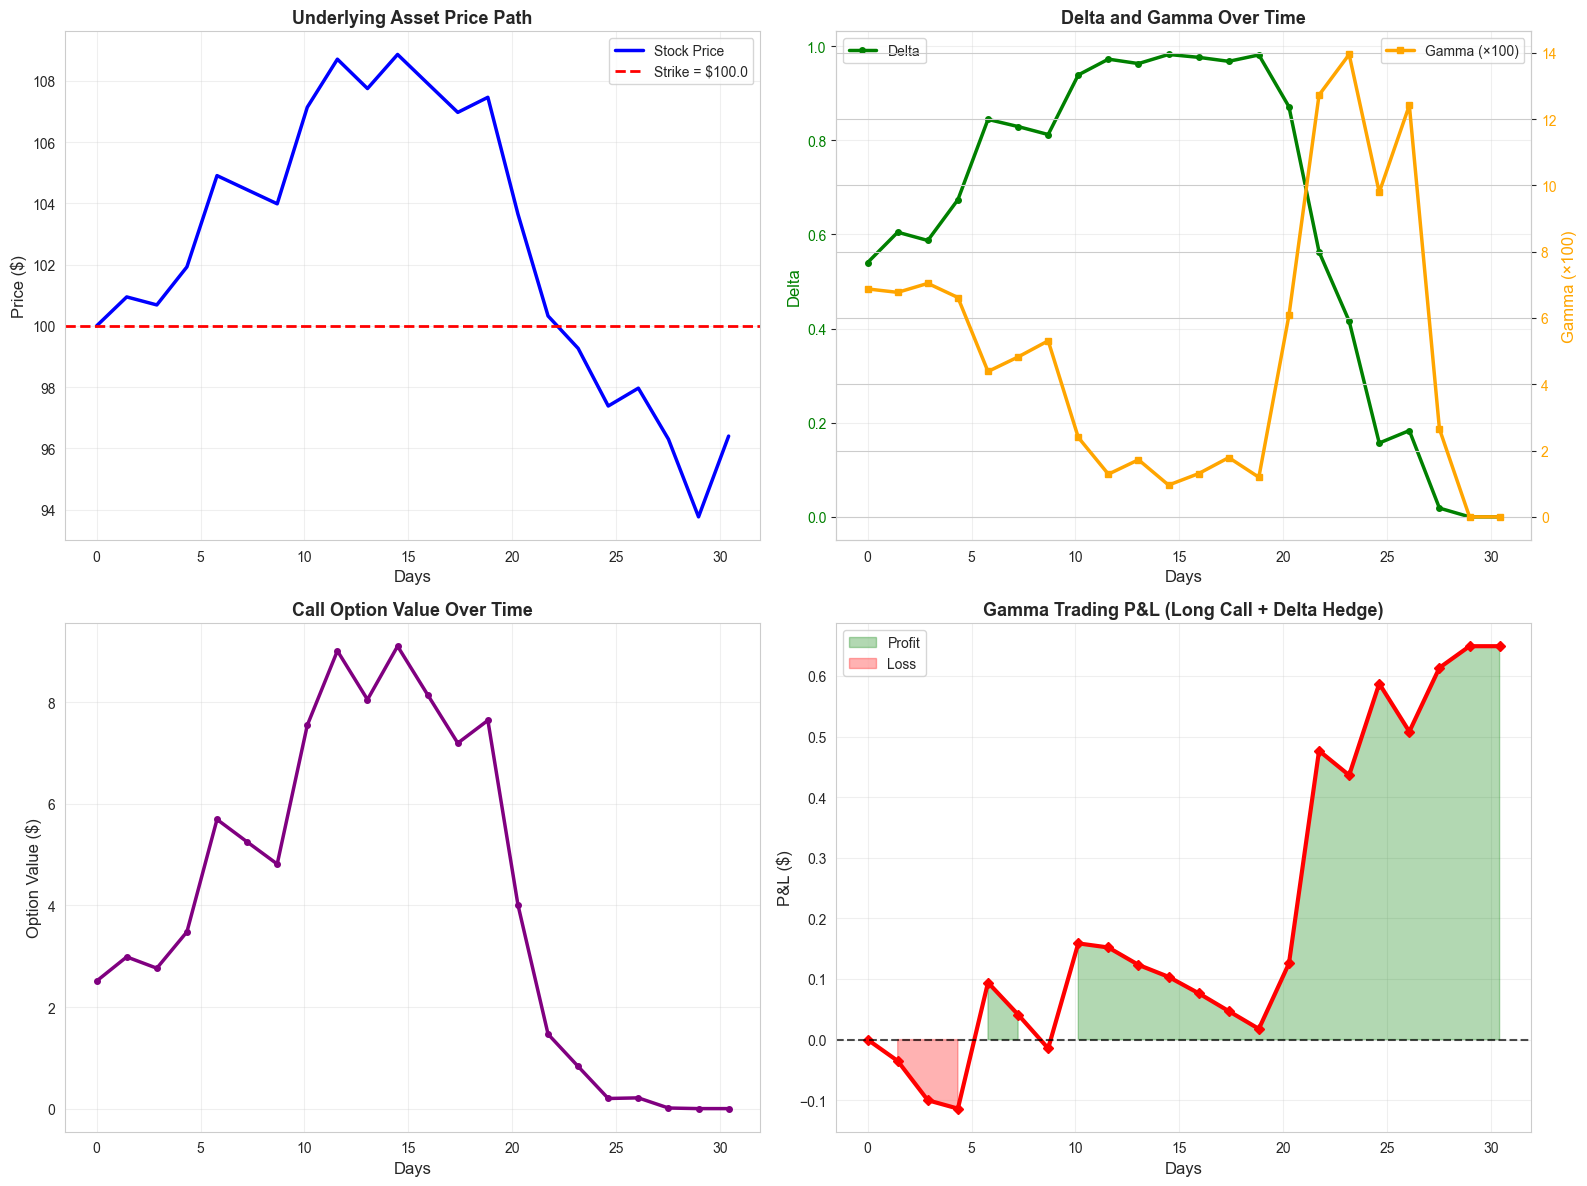


Portfolio Analysis:
Final option value: $0.0000
Final hedge position: -0.0000 shares
Final cash: $0.6490
Final P&L: $0.6490


In [6]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Stock price path
axes[0, 0].plot(df['Days'], df['Stock_Price'], 'b-', linewidth=2.5, label='Stock Price')
axes[0, 0].axhline(y=K, color='r', linestyle='--', linewidth=2, label=f'Strike = ${K}')
axes[0, 0].set_xlabel('Days', fontsize=12)
axes[0, 0].set_ylabel('Price ($)', fontsize=12)
axes[0, 0].set_title('Underlying Asset Price Path', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Delta and Gamma over time
ax2 = axes[0, 1]
ax2.plot(df['Days'], df['Delta'], 'g-', linewidth=2.5, label='Delta', marker='o', markersize=4)
ax2.set_xlabel('Days', fontsize=12)
ax2.set_ylabel('Delta', color='g', fontsize=12)
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_title('Delta and Gamma Over Time', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

ax2_twin = ax2.twinx()
ax2_twin.plot(df['Days'], df['Gamma']*100, 'orange', linewidth=2.5, 
              label='Gamma (×100)', marker='s', markersize=4)
ax2_twin.set_ylabel('Gamma (×100)', color='orange', fontsize=12)
ax2_twin.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='upper left', fontsize=10)
ax2_twin.legend(loc='upper right', fontsize=10)

# 3. Option value
axes[1, 0].plot(df['Days'], df['Option_Value'], 'purple', linewidth=2.5, marker='o', markersize=4)
axes[1, 0].set_xlabel('Days', fontsize=12)
axes[1, 0].set_ylabel('Option Value ($)', fontsize=12)
axes[1, 0].set_title('Call Option Value Over Time', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative P&L
axes[1, 1].plot(df['Days'], df['PnL'], 'r-', linewidth=3, marker='D', markersize=5)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1, 0].set_xlabel('Days', fontsize=12)
axes[1, 1].set_xlabel('Days', fontsize=12)
axes[1, 1].set_ylabel('P&L ($)', fontsize=12)
axes[1, 1].set_title('Gamma Trading P&L (Long Call + Delta Hedge)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].fill_between(df['Days'], 0, df['PnL'], where=(df['PnL'] >= 0), 
                        alpha=0.3, color='green', label='Profit')
axes[1, 1].fill_between(df['Days'], 0, df['PnL'], where=(df['PnL'] < 0), 
                        alpha=0.3, color='red', label='Loss')
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nPortfolio Analysis:")
print(f"Final option value: ${df.iloc[-1]['Option_Value']:.4f}")
print(f"Final hedge position: {df.iloc[-1]['Hedge_Position']:.4f} shares")
print(f"Final cash: ${df.iloc[-1]['Cash']:.4f}")
print(f"Final P&L: ${df.iloc[-1]['PnL']:.4f}")


## 6. Theoretical Analysis: P&L Formula

Derman presents an approximate formula for the expected P&L from gamma trading:

$$\text{PnL} \approx \frac{1}{2} \Gamma S^2 (\sigma_{\text{real}}^2 - \sigma_{\text{impl}}^2) T$$

Where:
- $\Gamma$ = Option gamma
- $S$ = Underlying price
- $\sigma_{\text{real}}$ = Realized volatility
- $\sigma_{\text{impl}}$ = Implied volatility  
- $T$ = Time to maturity

### Key Insight

The P&L depends on the **difference in variance** (not volatility), multiplied by time and gamma. This explains why:
- **Long gamma** profits when realized volatility > implied volatility
- **Short gamma** profits when realized volatility < implied volatility

Let's verify this formula with our simulation:


THEORETICAL FORMULA vs SIMULATION
Initial Gamma:        0.068747
Implied Volatility:   20.0%
Realized Volatility:  30.0%
Variance Difference:  0.0500

Theoretical P&L (Formula): $1.4322
Simulated P&L:            $1.3812
Difference:                $0.0510
Percentage Error:          3.56%


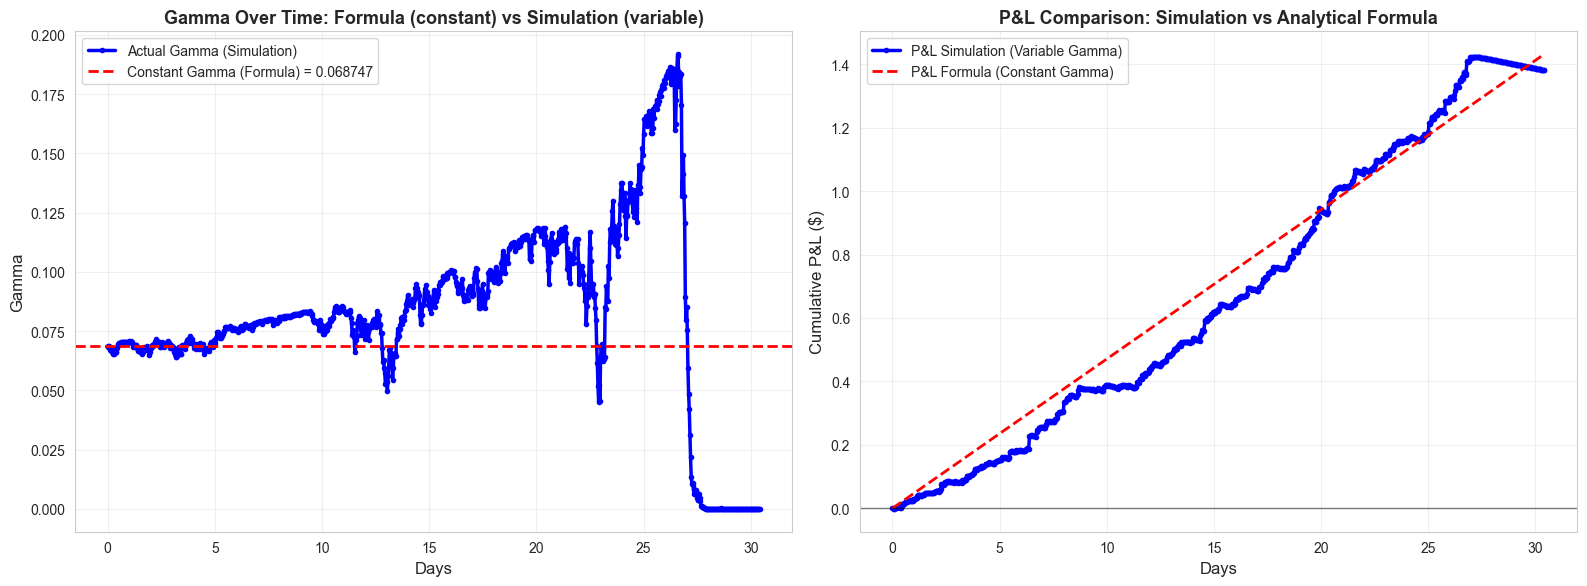


Note: The formula assumes constant gamma, but gamma actually changes with:
  - Stock price movements (moneyness)
  - Time to maturity
  - Volatility

Average gamma (simulation): 0.082898
Constant gamma (formula):   0.068747
Difference:                 0.014151


In [7]:
# Calculate theoretical P&L using Derman's formula
S = S0
K = 100.0
T_maturity = T
sigma_impl = 0.20
sigma_real = 0.30

# Calculate initial gamma
gamma_initial = gamma(S, K, T_maturity, r, sigma_impl)

# Derman's approximate formula
theoretical_pnl = 0.5 * gamma_initial * S**2 * (sigma_real**2 - sigma_impl**2) * T_maturity

# P&L from simulation (with more steps for accuracy)
df_actual = gamma_trading_simulation(S0, K, T, r, sigma_impl, sigma_real, 
                                     1000, rehedge_frequency=1, seed=42)
actual_pnl = df_actual.iloc[-1]['PnL']

print("="*80)
print("THEORETICAL FORMULA vs SIMULATION")
print("="*80)
print(f"Initial Gamma:        {gamma_initial:.6f}")
print(f"Implied Volatility:   {sigma_impl*100:.1f}%")
print(f"Realized Volatility:  {sigma_real*100:.1f}%")
print(f"Variance Difference:  {(sigma_real**2 - sigma_impl**2):.4f}")
print(f"\nTheoretical P&L (Formula): ${theoretical_pnl:.4f}")
print(f"Simulated P&L:            ${actual_pnl:.4f}")
print(f"Difference:                ${abs(theoretical_pnl - actual_pnl):.4f}")
print(f"Percentage Error:          {abs(theoretical_pnl - actual_pnl) / abs(theoretical_pnl) * 100:.2f}%")
print("="*80)

# Visualize gamma over time vs constant gamma assumption
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Variable Gamma vs Constant Gamma
axes[0].plot(df_actual['Days'], df_actual['Gamma'], 'b-', linewidth=2.5, 
             label='Actual Gamma (Simulation)', marker='o', markersize=3)
axes[0].axhline(y=gamma_initial, color='r', linestyle='--', linewidth=2, 
                label=f'Constant Gamma (Formula) = {gamma_initial:.6f}')
axes[0].set_xlabel('Days', fontsize=12)
axes[0].set_ylabel('Gamma', fontsize=12)
axes[0].set_title('Gamma Over Time: Formula (constant) vs Simulation (variable)', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: P&L Comparison
axes[1].plot(df_actual['Days'], df_actual['PnL'], 'b-', linewidth=2.5, 
             label='P&L Simulation (Variable Gamma)', marker='o', markersize=3)
# Approximate P&L using constant gamma (scaled linearly)
pnl_approx = [theoretical_pnl * (t / T_maturity) if T_maturity > 0 else 0 
              for t in df_actual['Time']]
axes[1].plot(df_actual['Days'], pnl_approx, 'r--', linewidth=2, 
             label='P&L Formula (Constant Gamma)')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Days', fontsize=12)
axes[1].set_ylabel('Cumulative P&L ($)', fontsize=12)
axes[1].set_title('P&L Comparison: Simulation vs Analytical Formula', 
                 fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: The formula assumes constant gamma, but gamma actually changes with:")
print(f"  - Stock price movements (moneyness)")
print(f"  - Time to maturity")
print(f"  - Volatility")
print(f"\nAverage gamma (simulation): {df_actual['Gamma'].mean():.6f}")
print(f"Constant gamma (formula):   {gamma_initial:.6f}")
print(f"Difference:                 {abs(df_actual['Gamma'].mean() - gamma_initial):.6f}")


## 7. Gamma vs Theta: The Fundamental Trade-off

When you are **long a call option** and **delta hedge**:
- **Long Gamma**: You benefit from market movements (profit from rehedging)
- **Short Theta**: You pay time decay every day

**Key Question**: How much must the underlying move each day to offset theta?

### Break-Even Daily Move

The P&L from gamma for a move ΔS is:
$$ \text{Gamma PnL} \approx \frac{1}{2} \Gamma (\Delta S)^2 $$

The daily theta decay is:
$$\text{Theta Decay} = \Theta \times dt$$

Break-even occurs when Gamma P&L = |Theta decay|:
$$\Delta S_{\text{break-even}} = \sqrt{\frac{2 |\Theta| \times dt}{\Gamma}}$$

This is approximately equal to the **daily implied volatility move**.


In [9]:
def calculate_breakeven_move(S, K, T, r, sigma):
    """
    Calculate the daily break-even move of the underlying asset
    necessary to offset theta decay.
    
    Returns:
    --------
    breakeven_move : float
        Break-even move in dollars
    breakeven_move_pct : float
        Break-even move as percentage
    gamma_val : float
        Current gamma
    theta_val : float
        Current theta (daily)
    """
    if T <= 0:
        return 0.0, 0.0, 0.0, 0.0
    
    # Calculate Greeks
    gamma_val = gamma(S, K, T, r, sigma)
    theta_val = theta_call(S, K, T, r, sigma)  # Already daily
    
    if gamma_val <= 0:
        return 0.0, 0.0, gamma_val, theta_val
    
    # Break-even move: sqrt(2 * |Theta| / Gamma)
    breakeven_move = np.sqrt(2 * abs(theta_val) / gamma_val)
    breakeven_move_pct = (breakeven_move / S) * 100  # In percentage
    
    return breakeven_move, breakeven_move_pct, gamma_val, theta_val

# Calculate for different maturities (ATM options)
S = 100.0
r = 0.05
sigma = 0.20

print("="*100)
print("BREAK-EVEN DAILY MOVE - ATM Options with Different Maturities")
print("="*100)
print(f"{'Maturity':<15} {'Gamma':<12} {'Theta/day':<12} {'BE Move $':<12} {'BE Move %':<12} {'Daily Vol %':<12}")
print("-"*100)

maturities_days = [7, 14, 21, 30, 60, 90, 180, 365]
results_maturity = []

for days in maturities_days:
    T_mat = days / 365
    K = S  # ATM
    be_move, be_move_pct, gamma_val, theta_val = calculate_breakeven_move(S, K, T_mat, r, sigma)
    
    # Calculate daily implied volatility
    daily_vol_pct = (sigma / np.sqrt(252)) * 100
    
    results_maturity.append({
        'Days': days,
        'Maturity': T_mat,
        'Gamma': gamma_val,
        'Theta': theta_val,
        'BE_Move': be_move,
        'BE_Move_Pct': be_move_pct,
        'Daily_Vol_Impl': daily_vol_pct
    })
    
    print(f"{days:>3} days       {gamma_val:>10.6f}  {theta_val:>10.4f}  ${be_move:>10.4f}  {be_move_pct:>10.4f}%  {daily_vol_pct:>10.4f}%")

df_maturity = pd.DataFrame(results_maturity)

print("="*100)
print("\nNote: BE Move % is the daily price movement (%) needed to offset theta decay.")
print("      If daily move > BE Move, Gamma P&L > |Theta| and we profit.")


BREAK-EVEN DAILY MOVE - ATM Options with Different Maturities
Maturity        Gamma        Theta/day    BE Move $    BE Move %    Daily Vol % 
----------------------------------------------------------------------------------------------------
  7 days         0.143869     -0.0858  $    1.0921      1.0921%      1.2599%
 14 days         0.101611     -0.0627  $    1.1107      1.1107%      1.2599%
 21 days         0.082868     -0.0524  $    1.1249      1.1249%      1.2599%
 30 days         0.069228     -0.0450  $    1.1401      1.1401%      1.2599%
 60 days         0.048706     -0.0338  $    1.1783      1.1783%      1.2599%
 90 days         0.039568     -0.0288  $    1.2075      1.2075%      1.2599%
180 days         0.027560     -0.0223  $    1.2734      1.2734%      1.2599%
365 days         0.018762     -0.0176  $    1.3687      1.3687%      1.2599%

Note: BE Move % is the daily price movement (%) needed to offset theta decay.
      If daily move > BE Move, Gamma P&L > |Theta| and we pro

### Break-Even Move vs Strike (Moneyness)

Now let's examine how the break-even move varies with moneyness (different strike prices):


In [10]:
# Test different strikes (moneyness) for fixed maturity
print("\n" + "="*100)
print("BREAK-EVEN DAILY MOVE - Different Strikes (Maturity = 30 days)")
print("="*100)
print(f"{'Strike':<10} {'Moneyness':<12} {'Gamma':<12} {'Theta/day':<12} {'BE Move $':<12} {'BE Move %':<12}")
print("-"*100)

T_fixed = 30 / 365
strikes = np.linspace(85, 115, 13)
results_strike = []

for K_strike in strikes:
    moneyness = (S / K_strike - 1) * 100  # % ITM/OTM
    be_move, be_move_pct, gamma_val, theta_val = calculate_breakeven_move(S, K_strike, T_fixed, r, sigma)
    
    results_strike.append({
        'Strike': K_strike,
        'Moneyness': moneyness,
        'Gamma': gamma_val,
        'Theta': theta_val,
        'BE_Move': be_move,
        'BE_Move_Pct': be_move_pct
    })
    
    moneyness_label = f"{moneyness:>+6.1f}%"
    print(f"{K_strike:>6.1f}    {moneyness_label:>10}  {gamma_val:>10.6f}  {theta_val:>10.4f}  ${be_move:>10.4f}  {be_move_pct:>10.4f}%")

df_strike = pd.DataFrame(results_strike)
print("="*100)



BREAK-EVEN DAILY MOVE - Different Strikes (Maturity = 30 days)
Strike     Moneyness    Gamma        Theta/day    BE Move $    BE Move %   
----------------------------------------------------------------------------------------------------
  85.0        +17.6%    0.000938     -0.0121  $    5.0763      5.0763%
  87.5        +14.3%    0.003640     -0.0138  $    2.7562      2.7562%
  90.0        +11.1%    0.010642     -0.0177  $    1.8260      1.8260%
  92.5         +8.1%    0.023965     -0.0247  $    1.4368      1.4368%
  95.0         +5.3%    0.042415     -0.0339  $    1.2651      1.2651%
  97.5         +2.6%    0.060076     -0.0420  $    1.1831      1.1831%
 100.0         +0.0%    0.069228     -0.0450  $    1.1401      1.1401%
 102.5         -2.4%    0.065883     -0.0410  $    1.1154      1.1154%
 105.0         -4.8%    0.052497     -0.0318  $    1.1001      1.1001%
 107.5         -7.0%    0.035464     -0.0211  $    1.0900      1.0900%
 110.0         -9.1%    0.020546     -0.0120  $  

## 8. Daily Analysis: Gamma P&L vs Theta P&L

Let's analyze a specific simulated path day-by-day:
- How much did the underlying move?
- What was the Gamma P&L?
- What was the Theta P&L?
- What was the net daily P&L?

This helps us understand the day-to-day dynamics of gamma trading.


In [12]:
def gamma_vs_theta_daily_analysis(S0, K, T, r, sigma_implied, sigma_realized, n_steps, seed=42):
    """
    Simulate a strategy and analyze daily P&L from Gamma vs Theta.
    
    Returns:
    --------
    DataFrame with daily analysis
    """
    # Simulate underlying price path
    prices, times = simulate_gbm(S0, r, sigma_realized, T, n_steps, seed)
    
    results = []
    
    for i in range(n_steps):
        S_today = prices[i]
        S_tomorrow = prices[i + 1]
        t_today = times[i]
        t_tomorrow = times[i + 1]
        
        ttm_today = T - t_today
        ttm_tomorrow = T - t_tomorrow
        dt = t_tomorrow - t_today
        
        if ttm_today <= 0:
            break
        
        # Greeks today
        gamma_today = gamma(S_today, K, ttm_today, r, sigma_implied)
        theta_today = theta_call(S_today, K, ttm_today, r, sigma_implied)
        
        # Underlying movement
        dS = S_tomorrow - S_today
        dS_pct = (dS / S_today) * 100
        
        # Calculate break-even move
        be_move = np.sqrt(2 * abs(theta_today) / gamma_today) if gamma_today > 0 else 0
        be_move_pct = (be_move / S_today) * 100
        
        # P&L from Gamma (approximated)
        gamma_pnl = 0.5 * gamma_today * (dS ** 2)
        
        # P&L from Theta
        theta_pnl = theta_today  # Already daily and negative
        
        # Net P&L (Gamma + Theta)
        net_pnl = gamma_pnl + theta_pnl
        
        # Was the move sufficient?
        move_sufficient = abs(dS) >= be_move
        
        results.append({
            'Day': i + 1,
            'Time': t_today,
            'S': S_today,
            'dS': dS,
            'dS_pct': dS_pct,
            'Abs_dS': abs(dS),
            'Abs_dS_pct': abs(dS_pct),
            'Gamma': gamma_today,
            'Theta': theta_today,
            'BE_Move': be_move,
            'BE_Move_Pct': be_move_pct,
            'Gamma_PnL': gamma_pnl,
            'Theta_PnL': theta_pnl,
            'Net_PnL': net_pnl,
            'Move_Sufficient': move_sufficient
        })
    
    return pd.DataFrame(results)

# Run daily analysis
S0 = 100.0
K = 100.0
T = 30 / 365  # 30 days
r = 0.05
sigma_impl = 0.20
sigma_real = 0.30  # High realized volatility
n_steps = 30

df_daily = gamma_vs_theta_daily_analysis(S0, K, T, r, sigma_impl, sigma_real, n_steps, seed=42)

print("="*120)
print("DAILY ANALYSIS: Gamma P&L vs Theta P&L")
print("="*120)
print(f"Option: ATM Call, Strike = ${K}, Maturity = 30 days")
print(f"Implied Volatility: {sigma_impl*100:.1f}% | Realized Volatility: {sigma_real*100:.1f}%")
print("="*120)
print(f"{'Day':<5} {'Stock':<8} {'Move $':<10} {'Move %':<10} {'BE %':<10} {'Suff?':<7} {'Gamma P&L':<12} {'Theta P&L':<12} {'Net P&L':<12}")
print("-"*120)

for idx, row in df_daily.head(15).iterrows():
    suff_marker = "✓" if row['Move_Sufficient'] else "✗"
    print(f"{row['Day']:<5.0f} ${row['S']:<7.2f} {row['dS']:>+9.3f} {row['dS_pct']:>+9.3f}% {row['BE_Move_Pct']:>9.3f}% "
          f"{suff_marker:>5}   ${row['Gamma_PnL']:>10.4f}  ${row['Theta_PnL']:>10.4f}  ${row['Net_PnL']:>10.4f}")

print("-"*120)
print(f"\nTotal Gamma P&L:  ${df_daily['Gamma_PnL'].sum():>10.4f}")
print(f"Total Theta P&L:  ${df_daily['Theta_PnL'].sum():>10.4f}")
print(f"Total Net P&L:    ${df_daily['Net_PnL'].sum():>10.4f}")
print(f"\nDays with sufficient move: {df_daily['Move_Sufficient'].sum()}/{len(df_daily)} "
      f"({df_daily['Move_Sufficient'].sum()/len(df_daily)*100:.1f}%)")
print("="*120)


DAILY ANALYSIS: Gamma P&L vs Theta P&L
Option: ATM Call, Strike = $100.0, Maturity = 30 days
Implied Volatility: 20.0% | Realized Volatility: 30.0%
Day   Stock    Move $     Move %     BE %       Suff?   Gamma P&L    Theta P&L    Net P&L     
------------------------------------------------------------------------------------------------------------------------
1     $100.00     +0.784    +0.784%     1.140%     ✗   $    0.0213  $   -0.0450  $   -0.0237
2     $100.78     -0.217    -0.216%     1.149%     ✗   $    0.0016  $   -0.0458  $   -0.0442
3     $100.57     +1.029    +1.024%     1.145%     ✗   $    0.0372  $   -0.0465  $   -0.0093
4     $101.60     +2.460    +2.422%     1.160%     ✓   $    0.2028  $   -0.0465  $    0.1563
5     $104.06     -0.380    -0.366%     1.219%     ✗   $    0.0037  $   -0.0407  $   -0.0370
6     $103.68     -0.379    -0.366%     1.206%     ✗   $    0.0039  $   -0.0424  $   -0.0385
7     $103.30     +2.595    +2.512%     1.194%     ✓   $    0.1953  $   -0.044

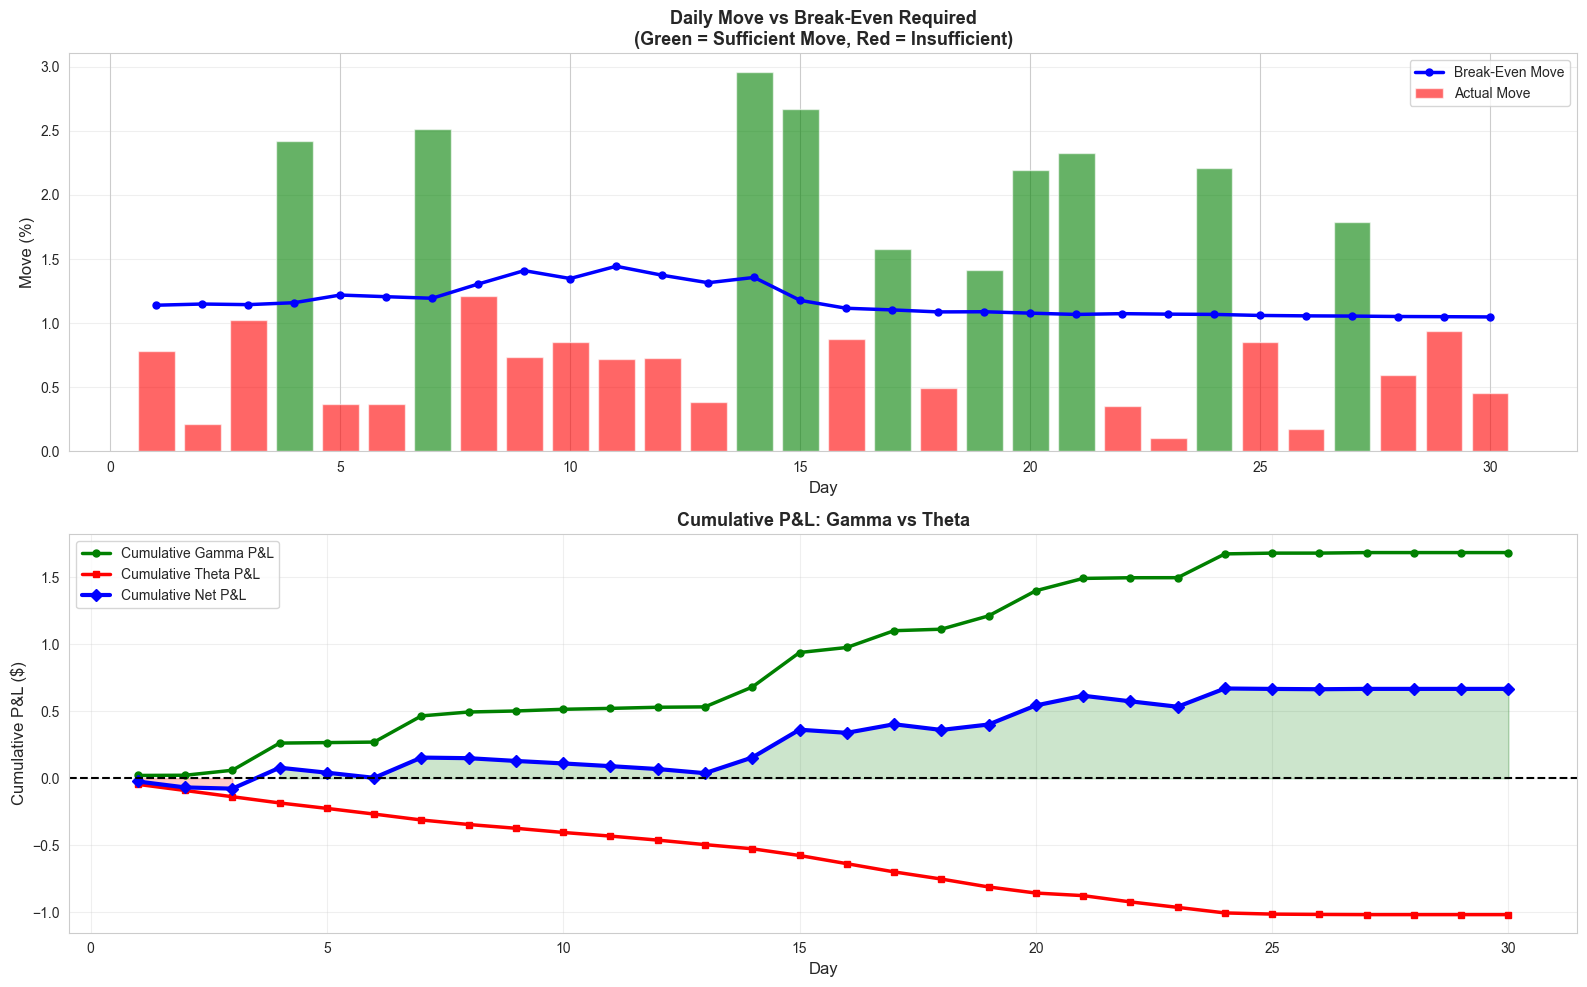


Interpretation:
• Green bars: Days where the move was sufficient to offset theta
• Red bars: Days where theta decay dominated
• Net P&L = Gamma P&L + Theta P&L
• When realized vol > implied vol, more days exceed break-even → positive P&L


In [13]:
# Daily analysis visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Daily move vs Break-Even
ax1 = axes[0]
days = df_daily['Day']
ax1.bar(days, df_daily['Abs_dS_pct'], alpha=0.6, 
        color=['green' if x else 'red' for x in df_daily['Move_Sufficient']], 
        label='Actual Move')
ax1.plot(days, df_daily['BE_Move_Pct'], 'b-', linewidth=2.5, marker='o', 
         markersize=5, label='Break-Even Move')
ax1.set_xlabel('Day', fontsize=12)
ax1.set_ylabel('Move (%)', fontsize=12)
ax1.set_title('Daily Move vs Break-Even Required\n(Green = Sufficient Move, Red = Insufficient)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative P&L
ax2 = axes[1]
cumulative_gamma = df_daily['Gamma_PnL'].cumsum()
cumulative_theta = df_daily['Theta_PnL'].cumsum()
cumulative_net = df_daily['Net_PnL'].cumsum()

ax2.plot(days, cumulative_gamma, 'g-', linewidth=2.5, marker='o', markersize=5, 
         label='Cumulative Gamma P&L')
ax2.plot(days, cumulative_theta, 'r-', linewidth=2.5, marker='s', markersize=5, 
         label='Cumulative Theta P&L')
ax2.plot(days, cumulative_net, 'b-', linewidth=3, marker='D', markersize=6, 
         label='Cumulative Net P&L')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Day', fontsize=12)
ax2.set_ylabel('Cumulative P&L ($)', fontsize=12)
ax2.set_title('Cumulative P&L: Gamma vs Theta', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.fill_between(days, 0, cumulative_net, where=(cumulative_net >= 0), 
                 alpha=0.2, color='green')
ax2.fill_between(days, 0, cumulative_net, where=(cumulative_net < 0), 
                 alpha=0.2, color='red')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("="*80)
print("• Green bars: Days where the move was sufficient to offset theta")
print("• Red bars: Days where theta decay dominated")
print("• Net P&L = Gamma P&L + Theta P&L")
print("• When realized vol > implied vol, more days exceed break-even → positive P&L")
print("="*80)


## Key Takeaways and Conclusions

### Summary of Key Concepts

1. **Long Gamma = Long Realized Volatility**
   - When you buy an option and delta hedge, you profit if realized volatility > implied volatility
   - The profit comes from rehedging: selling high and buying low as the market moves

2. **P&L Depends on Variance Difference**
   - The approximate formula: $\text{P\&L} \approx \frac{1}{2} \Gamma S^2 (\sigma_{\text{real}}^2 - \sigma_{\text{impl}}^2) T $
   - It's the **difference in variance** (not volatility) that matters
   - Multiplied by gamma, time, and stock price squared

3. **Gamma vs Theta Trade-off**
   - **Long Gamma**: Benefit from volatility (profit from rehedging)
   - **Short Theta**: Pay time decay every day
   - **Break-even move**: Daily price movement needed to offset theta
   - Formula: $\Delta S_{\text{BE}} = \sqrt{\frac{2|\Theta|}{\Gamma}}$

4. **Break-Even Move Insights**
   - Approximately equal to daily implied volatility: $\sigma \times \sqrt{dt} \times S$
   - Decreases as maturity increases (longer options need less movement)
   - Maximum for ATM options (where gamma is highest)

5. **Rehedging Frequency**
   - More frequent rehedging → closer to Black-Scholes theory (continuous hedging)
   - Less frequent rehedging → more tracking error but lower transaction costs
   - In practice, market makers rehedge multiple times per day

### Practical Applications

- **Market Makers**: Continuously manage gamma risk and calculate break-even moves
- **Volatility Traders**: Exploit discrepancies between implied and realized volatility
- **Risk Management**: Understanding gamma is fundamental for managing option portfolio risks
- **Trading Decisions**: Break-even move helps decide whether to buy or sell options

### References

- Derman, E., Miller, M. B., & Park, D. (2016). *The Volatility Smile*. Wiley.
- Chapter 3: "Gamma Trading"
